# DeepGuard AI — Image Forensics Walkthrough

This notebook demonstrates the classical (non-deep-learning) signal-processing
pipeline used by DeepGuard AI's backend (`app/ml_features.py`) to flag likely
synthetic/manipulated images.

The pipeline extracts four forensic signals from an image and combines them
into an explainable "fake probability" score:

1. **Noise-residual variance** — real camera sensors leave a fairly consistent
   high-frequency noise floor; GAN/diffusion output is often unnaturally smooth.
2. **Edge density** — generative models frequently over-smooth or over-sharpen
   edges relative to natural photographs.
3. **Frequency-domain (FFT) energy ratio** — synthetic images can show an
   anomalous high/low-frequency energy balance relative to real photos.
4. **Inter-channel correlation** — unnaturally uniform color blocks show
   very high R/G/B correlation compared to natural images.

We generate two classes of *synthetic test images* below (there's no claim these
perfectly mimic a real camera or a real GAN — they're illustrative proxies) to
show how each signal responds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from app.ml_features import (
    analyze_image_bytes,
    noise_residual_score,
    edge_density_score,
    frequency_energy_ratio,
    channel_correlation_score,
    _load_grayscale,
)

np.random.seed(0)
%matplotlib inline

## 1. Generate synthetic test images

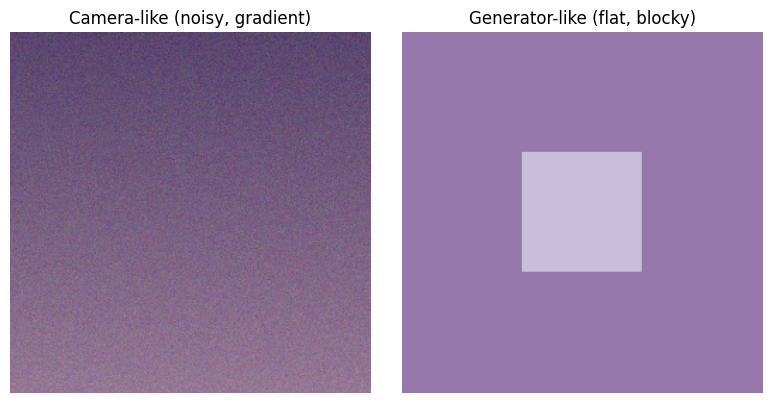

In [2]:
def camera_like_image(size=256, noise_std=8.0, seed=0):
    """Gradient base + per-pixel Gaussian noise — approximates real sensor noise."""
    rng = np.random.default_rng(seed)
    base = np.zeros((size, size, 3), dtype=np.float64)
    for i in range(size):
        base[i, :, 0] = 90 + i * (60 / size)
        base[i, :, 1] = 70 + i * (50 / size)
        base[i, :, 2] = 110 + i * (40 / size)
    noisy = np.clip(base + rng.normal(0, noise_std, base.shape), 0, 255).astype("uint8")
    return Image.fromarray(noisy)


def generator_like_image(size=256):
    """Flat, blocky color regions — approximates over-smoothed generator output."""
    arr = np.full((size, size, 3), (150, 120, 170), dtype="uint8")
    third = size // 3
    arr[third: 2 * third, third: 2 * third] = (200, 190, 220)
    return Image.fromarray(arr)


def to_bytes(pil_img):
    buf = io.BytesIO()
    pil_img.save(buf, format="PNG")
    return buf.getvalue()


img_camera = camera_like_image()
img_generator = generator_like_image()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_camera); axes[0].set_title("Camera-like (noisy, gradient)"); axes[0].axis("off")
axes[1].imshow(img_generator); axes[1].set_title("Generator-like (flat, blocky)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Run the full forensic pipeline on each

In [3]:
result_camera = analyze_image_bytes(to_bytes(img_camera))
result_generator = analyze_image_bytes(to_bytes(img_generator))

import json
print("Camera-like image:")
print(json.dumps(result_camera, indent=2))
print()
print("Generator-like image:")
print(json.dumps(result_generator, indent=2))

Camera-like image:
{
  "fake_probability": 27.5,
  "signals": {
    "noise_residual_variance": 569.429,
    "edge_density": 0.1559,
    "high_freq_energy_ratio": 0.8016,
    "channel_correlation": 0.7517
  },
  "artifacts": [
    "Anomalous high-frequency spectral energy (possible GAN/diffusion fingerprint)"
  ]
}

Generator-like image:
{
  "fake_probability": 77.6,
  "signals": {
    "noise_residual_variance": 39.063,
    "edge_density": 0.0207,
    "high_freq_energy_ratio": 0.2879,
    "channel_correlation": 1.0
  },
  "artifacts": [
    "Over-smoothed texture \u2014 noise residual below natural camera-sensor floor",
    "Anomalous high-frequency spectral energy (possible GAN/diffusion fingerprint)",
    "Edge density outside natural-photograph range",
    "Unusually strong inter-channel color correlation"
  ]
}


## 3. Compare individual signals side-by-side

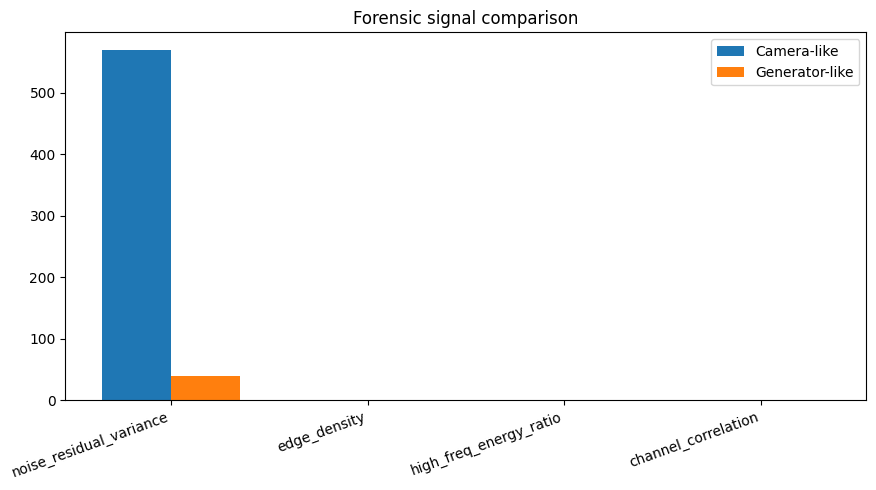

Camera-like fake probability:    27.5%
Generator-like fake probability: 77.6%


In [4]:
labels = ["noise_residual_variance", "edge_density", "high_freq_energy_ratio", "channel_correlation"]
camera_vals = [result_camera["signals"][k] for k in labels]
generator_vals = [result_generator["signals"][k] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, camera_vals, width, label="Camera-like")
ax.bar(x + width/2, generator_vals, width, label="Generator-like")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_title("Forensic signal comparison")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Camera-like fake probability:    {result_camera['fake_probability']}%")
print(f"Generator-like fake probability: {result_generator['fake_probability']}%")

## 4. Noise sensitivity sweep

How does the noise-residual signal respond as we vary the amount of injected
per-pixel noise? This should increase roughly monotonically — more sensor-like
noise, higher residual variance.

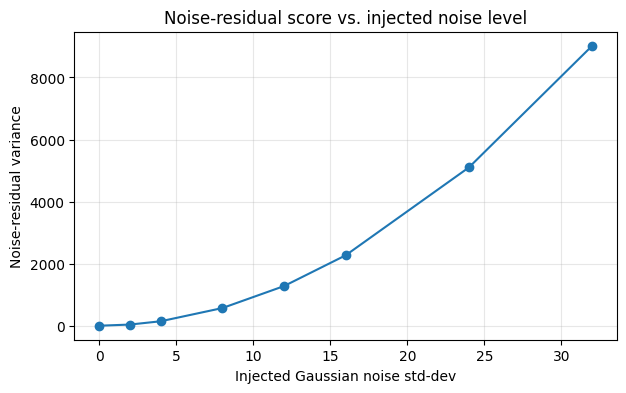

In [5]:
noise_levels = [0, 2, 4, 8, 12, 16, 24, 32]
residuals = []
for n in noise_levels:
    _, gray = _load_grayscale(to_bytes(camera_like_image(noise_std=n)))
    residuals.append(noise_residual_score(gray))

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, residuals, marker="o")
plt.xlabel("Injected Gaussian noise std-dev")
plt.ylabel("Noise-residual variance")
plt.title("Noise-residual score vs. injected noise level")
plt.grid(alpha=0.3)
plt.show()

## Notes / limitations

- These are **classical signal-processing heuristics**, not a trained deep
  learning classifier — they're explainable but not state-of-the-art.
- The synthetic test images above are simplified proxies; results on real
  photographs and real GAN/diffusion output will vary and should be
  validated against a labeled dataset before being trusted for production
  use.
- See `app/ml_features.py` for the full implementation and
  `tests/test_ml_features.py` for the automated test suite.